In [30]:
import numpy as np
import pandas as pd
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

In [31]:
# verify python version
!python --version

Python 3.10.11


In [39]:
# Specify the path to the CSV file
feature_engineering_path = "LOREAL.csv"

# Load the data and set the 'Date' column as the index
feature_engineering_data = pd.read_csv(feature_engineering_path, index_col='Date', parse_dates=True)


In [40]:
feature_engineering_data

,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,PriceToBook
Date,,,,,,,,,,,
12/01/2014,115.640204,116.315478,115.513596,115.851227,563831,76666.63,1.82,27.5,4.98,20.80,3.77
12/02/2014,116.273260,116.948534,115.724607,116.526489,628713,77113.50,1.81,27.7,4.98,20.93,3.79
12/03/2014,116.231064,117.159567,116.188857,116.399879,519450,77029.69,1.81,27.7,4.98,20.90,3.79
12/04/2014,116.231068,117.201778,114.289660,114.458489,1043572,75744.94,1.84,27.2,4.98,20.55,3.72
12/05/2014,115.809004,117.412781,115.386960,117.412781,821623,77700.00,1.80,27.9,4.98,21.09,3.82
...,...,...,...,...,...,...,...,...,...,...,...
25/11/2024,332.899994,336.049988,329.850006,333.700012,724569,178299.80,1.98,27.5,12.11,22.34,6.14
26/11/2024,331.149994,336.299988,328.399994,332.450012,322632,177631.90,1.99,27.4,12.11,22.25,6.11
27/11/2024,331.000000,333.399994,329.649994,332.850006,300479,177845.80,1.98,27.5,12.11,22.28,6.12


In [41]:
features_df = feature_engineering_data.copy()

In [42]:
# features_df['Date'] = pd.to_datetime(features_df['Date'])
# features_df.set_index('Date', inplace=True)  # Optional, if needed
features_df

,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,PriceToBook
Date,,,,,,,,,,,
12/01/2014,115.640204,116.315478,115.513596,115.851227,563831,76666.63,1.82,27.5,4.98,20.80,3.77
12/02/2014,116.273260,116.948534,115.724607,116.526489,628713,77113.50,1.81,27.7,4.98,20.93,3.79
12/03/2014,116.231064,117.159567,116.188857,116.399879,519450,77029.69,1.81,27.7,4.98,20.90,3.79
12/04/2014,116.231068,117.201778,114.289660,114.458489,1043572,75744.94,1.84,27.2,4.98,20.55,3.72
12/05/2014,115.809004,117.412781,115.386960,117.412781,821623,77700.00,1.80,27.9,4.98,21.09,3.82
...,...,...,...,...,...,...,...,...,...,...,...
25/11/2024,332.899994,336.049988,329.850006,333.700012,724569,178299.80,1.98,27.5,12.11,22.34,6.14
26/11/2024,331.149994,336.299988,328.399994,332.450012,322632,177631.90,1.99,27.4,12.11,22.25,6.11
27/11/2024,331.000000,333.399994,329.649994,332.850006,300479,177845.80,1.98,27.5,12.11,22.28,6.12


In [43]:
features_df.dtypes

Open               float64
High               float64
Low                float64
Close              float64
Volume               int64
MarketValue        float64
DividendYield      float64
PriceToEarnings    float64
EPS                float64
PriceToCash        float64
PriceToBook        float64
dtype: object

In [44]:
# features_df.ta.strategy(ta.AllStrategy())
features_df.ta.study("All", lookahead=False, talib=False)

[!] Pivots requires an ordered DatetimeIndex.
[!] VWAP requires an ordered DatetimeIndex.


TypeError: can only concatenate str (not "Timedelta") to str

In [77]:
specific_value = np.inf
specific_value2 = -np.inf
cols_with_infinity_values = [col for col in features_df.columns if specific_value in features_df[col].values or specific_value2 in features_df[col].values]
features_df.drop(columns=cols_with_infinity_values, axis=1, inplace=True)

In [78]:
features_df

,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,...,HA_close,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
12/01/2014,115.640204,116.315478,115.513596,115.851227,563831,76666.63,1.82,27.5,4.98,20.80,...,115.830127,15.109890,7.294430,0.756364,5.517241,NaN,NaN,NaN,NaN,1
12/02/2014,116.273260,116.948534,115.724607,116.526489,628713,77113.50,1.81,27.7,4.98,20.93,...,116.368223,15.303867,7.308707,0.755596,5.522427,3664.581929,NaN,NaN,0.005829,0
12/03/2014,116.231064,117.159567,116.188857,116.399879,519450,77029.69,1.81,27.7,4.98,20.90,...,116.494842,15.303867,7.308707,0.754513,5.514512,3100.182701,NaN,NaN,-0.001087,0
12/04/2014,116.231068,117.201778,114.289660,114.458489,1043572,75744.94,1.84,27.2,4.98,20.55,...,115.545249,14.782609,7.311828,0.755515,5.524194,-14305.172849,NaN,NaN,-0.016679,1
12/05/2014,115.809004,117.412781,115.386960,117.412781,821623,77700.00,1.80,27.9,4.98,21.09,...,116.505381,15.500000,7.303665,0.755914,5.520942,6901.768936,NaN,NaN,0.025811,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25/11/2024,332.899994,336.049988,329.850006,333.700012,724569,178299.80,1.98,27.5,12.11,22.34,...,333.125000,13.888889,4.478827,0.812364,3.638436,310401.923064,30.888889,10.521165,0.014132,0
26/11/2024,331.149994,336.299988,328.399994,332.450012,322632,177631.90,1.99,27.4,12.11,22.25,...,332.074997,13.768844,4.484452,0.812044,3.641571,309193.382503,32.888889,10.753656,-0.003746,1
27/11/2024,331.000000,333.399994,329.649994,332.850006,300479,177845.80,1.98,27.5,12.11,22.28,...,331.724998,13.888889,4.493464,0.810182,3.640523,309554.909839,34.444444,10.719497,0.001203,0


In [79]:
# 2. Price to Earnings to Dividend Ratio
features_df['PE_to_Dividend'] = features_df['PriceToEarnings'] / features_df['DividendYield']

# 3. Price to Earnings to Price to Book Combined Ratio
features_df['PE_to_PB'] = features_df['PriceToEarnings'] / features_df['PriceToBook']

# 4. Price to Cash to Earnings Combined Feature
features_df['PC_to_E'] = features_df['PriceToCash'] / features_df['PriceToEarnings']

# 5. Combined Valuation Metric (CWM)
features_df['CWM'] = (features_df['PriceToEarnings'] / features_df['PriceToBook']) * (features_df['PriceToCash'] / features_df['PriceToEarnings'])

# 6. On-Balance Volume (OBV)
features_df['OBV'] = (features_df['Volume'] * (features_df['Close'] > features_df['Close'].shift(1))).cumsum() - (features_df['Volume'] * (features_df['Close'] < features_df['Close'].shift(1))).cumsum()

# 7. Price Volume Trend (PVT)
features_df['PVT'] = ((features_df['Close'] - features_df['Close'].shift(1)) / features_df['Close'].shift(1)) * features_df['Volume']
features_df['PVT'] = features_df['PVT'].cumsum()


In [80]:
features_df

,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,...,HA_close,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
12/01/2014,115.640204,116.315478,115.513596,115.851227,563831,76666.63,1.82,27.5,4.98,20.80,...,115.830127,15.109890,7.294430,0.756364,5.517241,NaN,NaN,NaN,NaN,1
12/02/2014,116.273260,116.948534,115.724607,116.526489,628713,77113.50,1.81,27.7,4.98,20.93,...,116.368223,15.303867,7.308707,0.755596,5.522427,3664.581929,NaN,NaN,0.005829,0
12/03/2014,116.231064,117.159567,116.188857,116.399879,519450,77029.69,1.81,27.7,4.98,20.90,...,116.494842,15.303867,7.308707,0.754513,5.514512,3100.182701,NaN,NaN,-0.001087,0
12/04/2014,116.231068,117.201778,114.289660,114.458489,1043572,75744.94,1.84,27.2,4.98,20.55,...,115.545249,14.782609,7.311828,0.755515,5.524194,-14305.172849,NaN,NaN,-0.016679,1
12/05/2014,115.809004,117.412781,115.386960,117.412781,821623,77700.00,1.80,27.9,4.98,21.09,...,116.505381,15.500000,7.303665,0.755914,5.520942,6901.768936,NaN,NaN,0.025811,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25/11/2024,332.899994,336.049988,329.850006,333.700012,724569,178299.80,1.98,27.5,12.11,22.34,...,333.125000,13.888889,4.478827,0.812364,3.638436,310401.923064,30.888889,10.521165,0.014132,0
26/11/2024,331.149994,336.299988,328.399994,332.450012,322632,177631.90,1.99,27.4,12.11,22.25,...,332.074997,13.768844,4.484452,0.812044,3.641571,309193.382503,32.888889,10.753656,-0.003746,1
27/11/2024,331.000000,333.399994,329.649994,332.850006,300479,177845.80,1.98,27.5,12.11,22.28,...,331.724998,13.888889,4.493464,0.810182,3.640523,309554.909839,34.444444,10.719497,0.001203,0


Recurrence plot is a great way to visualize time series data to uncover hidden patterns, periodicity, or self-similarity. A recurrence plot is often used in analyzing dynamical systems, and it visualizes the times at which a state in a dynamical system recurs.

The recurrence plot itself is a binary matrix where values of 1 indicate recurrence and 0 means no recurrence. 
Percentage of Recurrence: How often the system recurs within a certain time window.
Entropy: How complex the system is, based on the plot.

The Close price data is first normalized using StandardScaler to make sure all features are on the same scale.

The recurrence_plot function generates a binary recurrence plot using the Euclidean distance between each pair of points in the series.
If the distance between two points is smaller than the threshold, it is considered a recurrence, and the corresponding entry in the matrix is set to 1 (otherwise 0).

Feature Extraction:
Recurrence Percentage: This feature calculates the percentage of recurrence points in the plot. - This gives you an idea of how often the system shows self-similarity or recurrence.
Recurrence Entropy: A measure of the unpredictability or complexity of the recurrence plot, computed as the Shannon entropy of the recurrence matrix. - A higher value means the system exhibits more complex behavior, while a lower value indicates regular, predictable behavior.

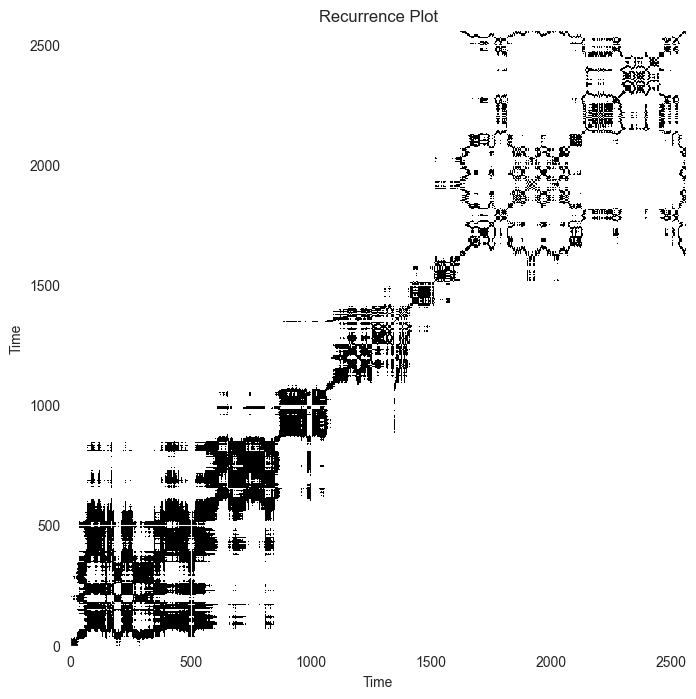

Recurrence Percentage: 8.178622161038563
Recurrence Entropy: 491.29735298658966


In [81]:
# Assuming 'features_df' is your DataFrame with a 'Close' column for time series data
import matplotlib.pyplot as plt
# Normalize the data first (you may use other techniques)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features_df[['Close']])

# Create a Recurrence Plot function
def recurrence_plot(data, threshold=0.1):
    """
    Generate a recurrence plot based on a distance threshold
    :param data: Time series data (2D array or DataFrame)
    :param threshold: Distance threshold for recurrence
    :return: Recurrence plot (binary matrix)
    """
    distance_matrix = cdist(data, data, 'euclidean')
    return (distance_matrix < threshold).astype(int)

# Generate Recurrence Plot for the 'Close' column
rp = recurrence_plot(data_scaled)

# Visualize the Recurrence Plot
plt.figure(figsize=(10, 8))
plt.imshow(rp, cmap='binary', origin='lower', interpolation='none')
plt.title('Recurrence Plot')
plt.xlabel('Time')
plt.ylabel('Time')
plt.show()

# Create a feature from the recurrence plot:
# Feature: Percentage of recurrence
recurrence_percentage = np.sum(rp) / rp.size * 100

# Feature: Recurrence entropy
def calculate_entropy(rp):
    """Calculate entropy from the recurrence plot."""
    prob_matrix = np.mean(rp, axis=0)
    prob_nonzero = prob_matrix[prob_matrix > 0]
    entropy = -np.sum(prob_nonzero * np.log(prob_nonzero))
    return entropy

recurrence_entropy = calculate_entropy(rp)

# Check the result
print(f"Recurrence Percentage: {recurrence_percentage}")
print(f"Recurrence Entropy: {recurrence_entropy}")


Recurrance Percentage - Value: 8.18%
Interpretation: This indicates that about 8.18% of the points in the time series recur within a certain threshold (as defined by the Euclidean distance). This percentage reflects how often similar states occur in the time series.
A higher recurrence percentage suggests more frequent patterns, periodicity, or stability in the time series.
A lower recurrence percentage suggests less frequent repetition of similar patterns or more randomness in the time series.

Recurrence Entropy:
Value: 491.30
Interpretation: This is a measure of the complexity or unpredictability of the system. High entropy indicates a more complex and chaotic system, while lower entropy suggests more regular or predictable behavior.
A higher recurrence entropy value means that the system is more complex and irregular, indicating greater unpredictability or randomness in the data.
A lower recurrence entropy means that the system follows a more regular, deterministic pattern.

Making the Features More Useful for LSTM
To make the Recurrence Percentage and Recurrence Entropy more useful for LSTM models, here are some strategies:
Sliding Window Approach:
Instead of calculating a single global value (like for the entire dataset), compute these features over a sliding window of a certain size (e.g., over the last 30 days). This will create time-varying features that capture the recurrence dynamics at different points in time.

This results in a feature matrix where these values change over time, making them more useful for LSTM models, which need dynamic, time-dependent features.

LSTMs are well-suited to work with time-varying features because they capture temporal dependencies, so features that reflect changing patterns over time (such as rolling recurrence features) will provide more valuable insights.

In [82]:
# Assuming 'features_df' is your DataFrame with a 'Close' column for time series data

# Normalize the data (if not already done)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features_df[['Close']])

# Create a Recurrence Plot function
def recurrence_plot(data, threshold=0.1):
    """
    Generate a recurrence plot based on a distance threshold
    :param data: Time series data (2D array or DataFrame)
    :param threshold: Distance threshold for recurrence
    :return: Recurrence plot (binary matrix)
    """
    distance_matrix = cdist(data, data, 'euclidean')
    return (distance_matrix < threshold).astype(int)

# Calculate Recurrence Features over a Sliding Window (e.g., 30-day window)
window_size = 30
recurrence_percentages = []
recurrence_entropies = []

for i in range(window_size, len(features_df)):
    window_data = data_scaled[i-window_size:i]
    
    # Generate the recurrence plot for the current window
    rp = recurrence_plot(window_data)
    
    # Feature: Recurrence Percentage
    recurrence_percentage = np.sum(rp) / rp.size * 100
    recurrence_percentages.append(recurrence_percentage)
    
    # Feature: Recurrence Entropy
    def calculate_entropy(rp):
        """Calculate entropy from the recurrence plot."""
        prob_matrix = np.mean(rp, axis=0)
        prob_nonzero = prob_matrix[prob_matrix > 0]
        entropy = -np.sum(prob_nonzero * np.log(prob_nonzero))
        return entropy

    recurrence_entropy = calculate_entropy(rp)
    recurrence_entropies.append(recurrence_entropy)

# Add the new features to the DataFrame
features_df['recurrence_percentage'] = [None] * window_size + recurrence_percentages
features_df['recurrence_entropy'] = [None] * window_size + recurrence_entropies

# Check the result
print(features_df[['recurrence_percentage', 'recurrence_entropy']].head())


            recurrence_percentage  recurrence_entropy
Date                                                 
12/01/2014                    NaN                 NaN
12/02/2014                    NaN                 NaN
12/03/2014                    NaN                 NaN
12/04/2014                    NaN                 NaN
12/05/2014                    NaN                 NaN


In [83]:
features_df

,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,...,HA_close,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
12/01/2014,115.640204,116.315478,115.513596,115.851227,563831,76666.63,1.82,27.5,4.98,20.80,...,115.830127,15.109890,7.294430,0.756364,5.517241,NaN,NaN,NaN,NaN,1
12/02/2014,116.273260,116.948534,115.724607,116.526489,628713,77113.50,1.81,27.7,4.98,20.93,...,116.368223,15.303867,7.308707,0.755596,5.522427,3664.581929,NaN,NaN,0.005829,0
12/03/2014,116.231064,117.159567,116.188857,116.399879,519450,77029.69,1.81,27.7,4.98,20.90,...,116.494842,15.303867,7.308707,0.754513,5.514512,3100.182701,NaN,NaN,-0.001087,0
12/04/2014,116.231068,117.201778,114.289660,114.458489,1043572,75744.94,1.84,27.2,4.98,20.55,...,115.545249,14.782609,7.311828,0.755515,5.524194,-14305.172849,NaN,NaN,-0.016679,1
12/05/2014,115.809004,117.412781,115.386960,117.412781,821623,77700.00,1.80,27.9,4.98,21.09,...,116.505381,15.500000,7.303665,0.755914,5.520942,6901.768936,NaN,NaN,0.025811,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25/11/2024,332.899994,336.049988,329.850006,333.700012,724569,178299.80,1.98,27.5,12.11,22.34,...,333.125000,13.888889,4.478827,0.812364,3.638436,310401.923064,30.888889,10.521165,0.014132,0
26/11/2024,331.149994,336.299988,328.399994,332.450012,322632,177631.90,1.99,27.4,12.11,22.25,...,332.074997,13.768844,4.484452,0.812044,3.641571,309193.382503,32.888889,10.753656,-0.003746,1
27/11/2024,331.000000,333.399994,329.649994,332.850006,300479,177845.80,1.98,27.5,12.11,22.28,...,331.724998,13.888889,4.493464,0.810182,3.640523,309554.909839,34.444444,10.719497,0.001203,0


In [84]:
# Export the DataFrame to an Excel file
features_df.to_excel('features_df.xlsx', index=False)


In [85]:
# Calculate daily returns (current day)
features_df['daily_return'] = features_df['Close'].pct_change()

# Shift the label to represent the next day's movement
features_df['y'] = np.where(features_df['daily_return'].shift(-1) > 0, 1, 0)

# Now, 'y' is the binary target variable for the 1 day forward looking classification problem

In [86]:
# drop unwanted features columns
features_df.drop(['EOM_14_100000000', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'PSARaf_0.02_0.2','HILOs_13_21','HILOl_13_21', 'PSARr_0.02_0.2', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'SUPERTd_7_3.0','SUPERT_7_3.0', 'ZIGZAGs_5.0%_10', 'ZIGZAGv_5.0%_10', 'ZIGZAGd_5.0%_10', 'VIDYA_14', 'VHM_610'], axis=1, inplace=True)

KeyError: "['EOM_14_100000000', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 'PSARaf_0.02_0.2', 'HILOs_13_21', 'HILOl_13_21', 'PSARr_0.02_0.2', 'SUPERTl_7_3.0', 'SUPERTs_7_3.0', 'SUPERTd_7_3.0', 'SUPERT_7_3.0', 'ZIGZAGs_5.0%_10', 'ZIGZAGv_5.0%_10', 'ZIGZAGd_5.0%_10', 'VIDYA_14', 'VHM_610'] not found in axis"

In [87]:
# Check the total number of NaN values in each column
nan_counts = features_df.isna().sum()

# Display the total NaN counts for each column
print(nan_counts)

Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
                         ..
PVT                       1
recurrence_percentage    30
recurrence_entropy       30
daily_return              1
y                         0
Length: 169, dtype: int64


In [88]:
# Export the NaN counts to a CSV file
nan_counts.to_csv('nan_counts.csv', header=True)

# Output the path where the CSV file is saved
'nan_counts.csv'

'nan_counts.csv'

In [89]:
# Drop rows with NaN values and assign the result to a new dataframe
features_df_nonull = features_df.dropna()

# Display the updated DataFrame
features_df_nonull


,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,...,HA_close,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
27/04/2015,148.137629,151.556193,146.322843,151.302963,709393,100600.50,1.51,21.1,8.51,22.71,...,149.329907,13.973510,4.964706,1.076303,5.343529,243417.120689,100.000000,-0.000000,0.019915,0
28/04/2015,150.627684,150.880913,145.563150,146.871490,752047,97654.06,1.55,20.5,8.51,22.04,...,148.485809,13.225806,4.963680,1.075122,5.336562,221390.613395,100.000000,-0.000000,-0.029289,0
29/04/2015,146.913707,148.475264,142.819870,142.819870,820080,94960.13,1.60,19.9,8.51,21.44,...,145.257178,12.437500,4.962594,1.077387,5.346633,198767.754947,100.000000,-0.000000,-0.027586,1
30/04/2015,142.651043,145.183310,141.173887,143.874969,900945,95661.69,1.58,20.0,8.51,21.59,...,143.220802,12.658228,4.950495,1.079500,5.344059,205423.597856,100.000000,-0.000000,0.007388,1
05/04/2015,145.563158,147.124728,144.043795,146.322845,567817,97289.25,1.56,20.4,8.51,21.96,...,145.763631,13.076923,4.963504,1.076471,5.343066,215084.386049,100.000000,-0.000000,0.017014,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22/11/2024,324.149994,331.100006,323.100006,329.049988,477166,175815.30,2.01,27.2,12.11,22.02,...,326.849998,13.532338,4.495868,0.809559,3.639669,300162.556237,28.666667,10.368556,0.019046,1
25/11/2024,332.899994,336.049988,329.850006,333.700012,724569,178299.80,1.98,27.5,12.11,22.34,...,333.125000,13.888889,4.478827,0.812364,3.638436,310401.923064,30.888889,10.521165,0.014132,0
26/11/2024,331.149994,336.299988,328.399994,332.450012,322632,177631.90,1.99,27.4,12.11,22.25,...,332.074997,13.768844,4.484452,0.812044,3.641571,309193.382503,32.888889,10.753656,-0.003746,1


In [90]:
features_df_nonull.head()

,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,...,HA_close,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
Date,,,,,,,,,,,,,,,,,,,,,
27/04/2015,148.137629,151.556193,146.322843,151.302963,709393,100600.50,1.51,21.1,8.51,22.71,...,149.329907,13.973510,4.964706,1.076303,5.343529,243417.120689,100.0,-0.0,0.019915,0
28/04/2015,150.627684,150.880913,145.563150,146.871490,752047,97654.06,1.55,20.5,8.51,22.04,...,148.485809,13.225806,4.963680,1.075122,5.336562,221390.613395,100.0,-0.0,-0.029289,0
29/04/2015,146.913707,148.475264,142.819870,142.819870,820080,94960.13,1.60,19.9,8.51,21.44,...,145.257178,12.437500,4.962594,1.077387,5.346633,198767.754947,100.0,-0.0,-0.027586,1
30/04/2015,142.651043,145.183310,141.173887,143.874969,900945,95661.69,1.58,20.0,8.51,21.59,...,143.220802,12.658228,4.950495,1.079500,5.344059,205423.597856,100.0,-0.0,0.007388,1
05/04/2015,145.563158,147.124728,144.043795,146.322845,567817,97289.25,1.56,20.4,8.51,21.96,...,145.763631,13.076923,4.963504,1.076471,5.343066,215084.386049,100.0,-0.0,0.017014,0


In [91]:
daily_return_description = features_df_nonull['daily_return'].describe()

print(daily_return_description)

count    2461.000000
mean        0.000424
std         0.014216
min        -0.075803
25%        -0.007121
50%         0.000559
75%         0.007716
max         0.084374
Name: daily_return, dtype: float64


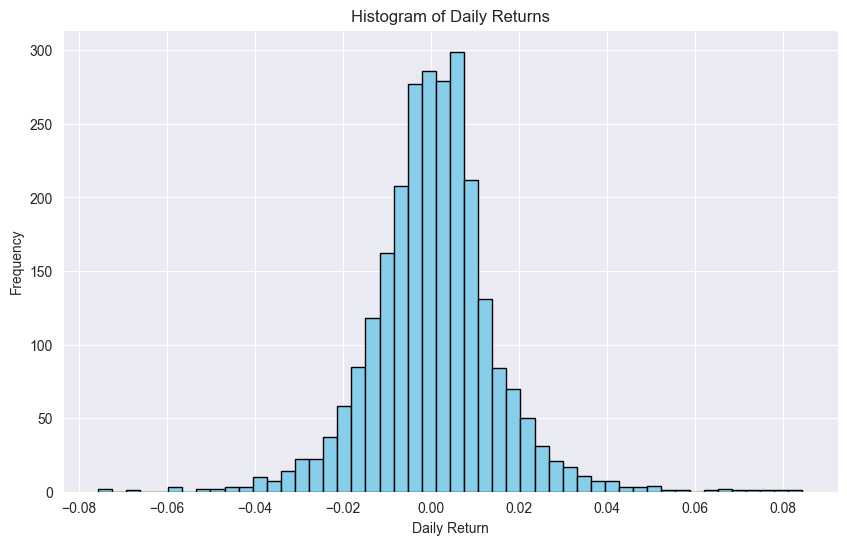

In [92]:
import matplotlib.pyplot as plt

# Plot histogram for the daily returns to understand the distribution
plt.figure(figsize=(10, 6))
plt.hist(features_df['daily_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histogram of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()


In [93]:
features_df_nonull = features_df_nonull.astype(float)

In [94]:
features_df_nonull['y'] = features_df_nonull['y'].astype(int)

In [95]:
print(features_df_nonull.dtypes.value_counts())

float64    168
int64        1
Name: count, dtype: int64


In [96]:
# Calculate the variance of each feature (ignoring the target column 'y')
feature_variance = features_df_nonull.drop('y', axis=1).var()

# Display the variance of each feature
print(feature_variance)


Open                     1.008761e+04
High                     1.027119e+04
Low                      9.901455e+03
Close                    1.008759e+04
Volume                   6.263089e+10
                             ...     
CWM                      5.257485e-01
PVT                      1.842530e+10
recurrence_percentage    4.892511e+02
recurrence_entropy       1.607248e+01
daily_return             2.021076e-04
Length: 168, dtype: float64


In [97]:
# Set the threshold for low variance
variance_threshold = 0.1

# Identify low variance features
low_variance_features = feature_variance[feature_variance < variance_threshold].index

print(f"Low variance features: {low_variance_features}")


Low variance features: Index(['DividendYield', 'BBP_5_2.0', 'BIAS_SMA_26', 'CDL_3STARSINSOUTH',
       'CDL_ABANDONEDBABY', 'CDL_CONCEALBABYSWALL', 'CDL_IDENTICAL3CROWS',
       'CDL_KICKING', 'CDL_KICKINGBYLENGTH', 'CDL_MATHOLD', 'CG_10', 'CMF_20',
       'ENTP_10', 'ER_10', 'PC_to_E', 'daily_return'],
      dtype='object')


Even though a feature may exhibit low variance, it could still hold valuable information under certain conditions. For instance, a feature that mostly assumes a constant value but changes under specific circumstances could be highly informative about those conditions. Therefore, the decision to remove a low variance feature should be well-considered, weighing the potential loss of subtle but important data against the simplicity and efficiency gained by its exclusion.

In [98]:
# Get summary statistics for all numerical features
features_df_nonull.describe()


,Open,High,Low,Close,Volume,MarketValue,DividendYield,PriceToEarnings,EPS,PriceToCash,...,HA_close,PE_to_Dividend,PE_to_PB,PC_to_E,CWM,PVT,recurrence_percentage,recurrence_entropy,daily_return,y
count,2461.000000,2461.000000,2461.000000,2461.000000,2.461000e+03,2461.000000,2461.000000,2461.000000,2461.000000,2461.000000,...,2461.000000,2461.000000,2461.000000,2461.000000,2461.000000,2461.000000,2461.000000,2461.000000,2461.000000,2461.000000
mean,259.513306,261.872953,257.083139,259.586151,4.887467e+05,152322.902397,1.533742,35.759854,7.800163,24.350943,...,259.513888,25.236300,6.574093,0.709014,4.546445,258053.198894,74.993002,5.008200,0.000424,0.517269
std,100.437090,101.346866,99.506054,100.436989,2.502616e+05,50456.225016,0.279152,9.583042,2.036590,3.987076,...,100.419570,11.778471,1.338595,0.138918,0.725085,135739.823740,22.119021,4.009050,0.014216,0.499803
min,123.772056,125.615561,120.385151,123.386192,0.000000e+00,80542.880000,0.930000,16.000000,5.190000,17.110000,...,124.243643,8.510638,4.478827,0.487154,3.635914,-80521.980393,26.666667,-0.000000,-0.075803,0.000000
25%,162.303164,162.792444,160.993300,161.954437,3.290780e+05,101963.200000,1.320000,30.000000,6.370000,21.010000,...,161.991812,16.666667,5.057971,0.616129,3.698675,144107.316304,55.333333,0.505615,-0.007121,0.000000
50%,236.474390,238.408191,234.448533,236.013962,4.349450e+05,143418.800000,1.560000,34.600000,6.960000,24.060000,...,236.036998,22.165605,6.914894,0.691489,5.059322,300673.528436,77.777778,5.196302,0.000559,1.000000
75%,350.755462,354.933839,347.995618,351.157929,5.813290e+05,201195.200000,1.770000,39.500000,9.000000,27.140000,...,350.504137,31.544118,7.570093,0.738056,5.182825,374383.028633,98.222222,8.993544,0.007716,1.000000
max,457.950012,461.850006,456.149994,456.899994,2.569157e+06,244315.900000,2.070000,61.400000,12.110000,36.090000,...,457.824997,63.225806,8.931860,1.143478,5.350000,453524.478626,100.000000,10.946127,0.084374,1.000000


In [99]:
# Calculate skewness and kurtosis for each feature
skewness = features_df_nonull.skew()
kurtosis = features_df_nonull.kurtosis()

# Combine skewness and kurtosis into a single DataFrame
skew_kurt_df = pd.DataFrame({
    'Feature': features_df_nonull.columns,
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

# Save the DataFrame to a CSV file
skew_kurt_df.to_csv('skewness_kurtosis_summary.csv', index=False)

# Optionally, print the first few rows to check the output
print(skew_kurt_df.head())


       Feature  Skewness  Kurtosis
Open      Open  0.316709 -1.331575
High      High  0.310636 -1.341464
Low        Low  0.322340 -1.321803
Close    Close  0.314904 -1.332396
Volume  Volume  2.221247  9.262991


In [100]:
# Checking the class distribution in the 'y' column
y_class_distribution = features_df_nonull['y'].value_counts()
print(y_class_distribution)


y
1    1273
0    1188
Name: count, dtype: int64


In [101]:
print(features_df_nonull.isna().sum())

Open                     0
High                     0
Low                      0
Close                    0
Volume                   0
                        ..
PVT                      0
recurrence_percentage    0
recurrence_entropy       0
daily_return             0
y                        0
Length: 169, dtype: int64


In [102]:
# Calculate correlation between all features and the target 'y'
corr_matrix = features_df_nonull.corr()

# Extract the correlation of each feature with the target 'y'
target_corr = corr_matrix['y'].sort_values(ascending=False)

# Display the correlation between each feature and 'y'
print(target_corr)


y                       1.000000
DEC_1                   0.080551
EXHC_DNa                0.058662
PE_to_PB                0.044199
AMATe_SR_8_21_2         0.037624
                          ...   
CDL_CONCEALBABYSWALL         NaN
CDL_IDENTICAL3CROWS          NaN
CDL_KICKING                  NaN
CDL_KICKINGBYLENGTH          NaN
CDL_MATHOLD                  NaN
Name: y, Length: 169, dtype: float64


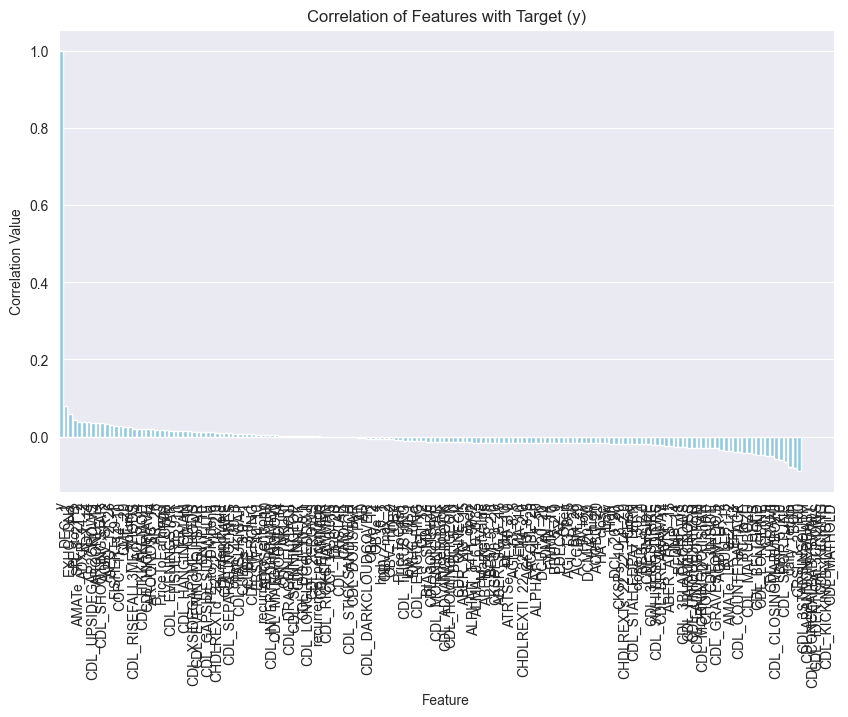

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Plot the correlation of features with 'y'
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.index, y=target_corr.values, color='skyblue')  # Using color instead of palette
plt.title('Correlation of Features with Target (y)')
plt.xlabel('Feature')
plt.ylabel('Correlation Value')
plt.xticks(rotation=90)  # Rotate feature names for readability
plt.show()


In [104]:
# Step 4: Remove highly correlated features (correlation > 0.9)
# Exclude the target 'y' from the correlation calculation
features_without_y = features_df_nonull.drop('y', axis=1)

# Calculate the correlation matrix of the features excluding 'y'
corr_matrix = features_without_y.corr()

# Find the features with high correlation with 'y' (threshold = 0.9)
high_corr_features = target_corr[abs(target_corr) > 0.9].index

# Ensure that 'y' is not removed by excluding it from the drop list
high_corr_features = [feature for feature in high_corr_features if feature != 'y']

# Remove the features with high correlation (except for 'y')
features_df_cleaned = features_df_nonull.drop(columns=high_corr_features)

# Display the cleaned DataFrame shape
print(f"Shape before removing features: {features_df_nonull.shape}")
print(f"Shape after removing features: {features_df_cleaned.shape}")


Shape before removing features: (2461, 169)
Shape after removing features: (2461, 169)


In [105]:
# List columns with NaN values
columns_with_na = features_df_cleaned.columns[features_df_cleaned.isna().any()].tolist()

# Display the columns with NaN values
columns_with_na

[]

In [106]:
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# Load your data
# Assuming 'features_df_cleaned' is your DataFrame and 'y' is the target variable
X = features_df_cleaned.drop(columns=['y'])  
y = features_df_cleaned['y']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# # Step 1: 
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# Train a Random Forest model
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Metrics 
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(acc, f1)

0.5598377281947262 0.559152255586868


In [107]:
print(y_pred[:10], y_test[:10].values)


[0 0 0 0 0 0 0 0 0 0] [1 0 1 1 1 0 1 1 0 1]


In [108]:
features_list = X.columns

# Step 1: Boruta Feature Selection
boruta = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=0)

# Scale the feature set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert X_train and y_train to numpy arrays for Boruta
X_train_array = X_train_scaled  # Already a NumPy array
y_train_array = y_train.values  # Convert y_train to NumPy array if it's a pandas Series

# Fit Boruta
boruta.fit(X_train_array, y_train_array)

# Retrieve selected features using list comprehension
boruta_selected_features = list(features_list[boruta.support_])

# Transform data using Boruta-selected features
X_train_filtered = pd.DataFrame(boruta.transform(X_train_array), columns=boruta_selected_features)
X_test_filtered = pd.DataFrame(boruta.transform(X_test_scaled), columns=boruta_selected_features)

# Train a Random Forest model with Boruta-selected features
rf.fit(X_train_filtered, y_train)
y_pred = rf.predict(X_test_filtered)

# Metrics for Boruta
acc_boruta = accuracy_score(y_test, y_pred)
f1_boruta = f1_score(y_test, y_pred)

print(f"Boruta Accuracy: {acc_boruta}, F1 Score: {f1_boruta}")
print(f"Number of Selected Features by Boruta: {len(boruta_selected_features)}")

# Step 2: Recursive Feature Elimination (RFE)
rfe = RFE(estimator=rf, n_features_to_select=10)  
rfe.fit(X_train_filtered, y_train)

# Select RFE features
rfe_selected_features = list(X_train_filtered.columns[rfe.support_])
X_train_rfe = X_train_filtered[rfe_selected_features]
X_test_rfe = X_test_filtered[rfe_selected_features]

# Train a Random Forest model with RFE-selected features
rf.fit(X_train_rfe, y_train)
y_pred_rfe = rf.predict(X_test_rfe)

# Metrics for RFE
acc_rfe = accuracy_score(y_test, y_pred_rfe)
f1_rfe = f1_score(y_test, y_pred_rfe)

# Step 3: Multicollinearity Filtering
correlation_matrix = X_train_rfe.corr().abs()
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]
X_train_multicollinear = X_train_rfe.drop(columns=to_drop)
X_test_multicollinear = X_test_rfe.drop(columns=to_drop)

# Train a Random Forest model with multicollinearity-filtered features
rf.fit(X_train_multicollinear, y_train)
y_pred_multicollinear = rf.predict(X_test_multicollinear)

# Metrics for Multicollinearity Filtering
acc_multicollinear = accuracy_score(y_test, y_pred_multicollinear)
f1_multicollinear = f1_score(y_test, y_pred_multicollinear)

# Summary of feature selection
summary = pd.DataFrame({
    'Stage': ['Boruta', 'RFE', 'Multicollinearity'],
    'Number of Features': [len(boruta_selected_features), len(rfe_selected_features), X_train_multicollinear.shape[1]],
    'Accuracy Score': [acc_boruta, acc_rfe, acc_multicollinear],
    'F1 Score': [f1_boruta, f1_rfe, f1_multicollinear]
})

print(summary)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	168
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	168
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	168
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	168
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	168
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	168
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	168
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	9 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	10 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	11 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	12 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	13 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	14 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	15 / 100
Confirmed: 	0
Tentative: 	7
Rejected: 	161
Iteration: 	16 / 100
Confirmed: 	0
Tentative: 	7


/Users/calebfowowe/Documents/Programming/ML_wrks/.venv/lib/python3.10/site-packages/sklearn/feature_selection/_rfe.py:291: UserWarning: Found n_features_to_select=10 > n_features=2. There will be no feature selection and all features will be kept.
  warnings.warn(


               Stage  Number of Features  Accuracy Score  F1 Score
0             Boruta                   2        0.523327  0.540117
1                RFE                   2        0.535497  0.529774
2  Multicollinearity                   2        0.529412  0.534137


In [109]:
X.shape

(2461, 168)

In [110]:
y.shape

(2461,)

In [111]:
print(X_test_multicollinear.dtypes)


CRSI_3_2_100    float64
daily_return    float64
dtype: object


In [112]:
# Selecting the final features based on the feature selection steps
selected_features = [
    'RSI', 'log_returns', 'lagged_return_5', 'O_C', 
    'stochastic_oscillator', 'Force_Index', 'VROC_3m'
]

# Create the final dataframe with selected features and the target variable 'y'
final_df_lstm = features_df_cleaned[selected_features + ['y']]


KeyError: "['RSI', 'log_returns', 'lagged_return_5', 'O_C', 'stochastic_oscillator', 'Force_Index', 'VROC_3m'] not in index"

In [113]:
final_df_lstm

NameError: name 'final_df_lstm' is not defined

In [ ]:
final_df_lstm.shape

In [ ]:
final_df_lstm.to_csv('final_df_lstm.csv', index=True)
